In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', 100)
pd.set_option('display.float_format', lambda x: '%.3f' % x)

print("Loading all datasets...")

train        = pd.read_csv(r'C:\Users\Priyanshi Mittal\home-credit-default-risk\data\application_train.csv')
test         = pd.read_csv(r'C:\Users\Priyanshi Mittal\home-credit-default-risk\data\application_test.csv')
bureau       = pd.read_csv(r'C:\Users\Priyanshi Mittal\home-credit-default-risk\data\bureau.csv')
bur_bal      = pd.read_csv(r'C:\Users\Priyanshi Mittal\home-credit-default-risk\data\bureau_balance.csv')
prev_app     = pd.read_csv(r'C:\Users\Priyanshi Mittal\home-credit-default-risk\data\previous_application.csv')
pos_cash     = pd.read_csv(r'C:\Users\Priyanshi Mittal\home-credit-default-risk\data\POS_CASH_balance.csv')
credit_card  = pd.read_csv(r'C:\Users\Priyanshi Mittal\home-credit-default-risk\data\credit_card_balance.csv')
installments = pd.read_csv(r'C:\Users\Priyanshi Mittal\home-credit-default-risk\data\installments_payments.csv')

print(f"train:        {train.shape}")
print(f"test:         {test.shape}")
print(f"bureau:       {bureau.shape}")
print(f"bur_balance:  {bur_bal.shape}")
print(f"prev_app:     {prev_app.shape}")
print(f"pos_cash:     {pos_cash.shape}")
print(f"credit_card:  {credit_card.shape}")
print(f"installments: {installments.shape}")

Loading all datasets...
train:        (307511, 122)
test:         (48744, 121)
bureau:       (1716428, 17)
bur_balance:  (27299925, 3)
prev_app:     (1670214, 37)
pos_cash:     (10001358, 8)
credit_card:  (3840312, 23)
installments: (13605401, 8)


In [2]:
def aggregate_table(df, group_col, prefix):
    """
    Aggregates a supplementary table by group_col.
    - Numerical columns: mean, max, min, sum, std
    - Result is prefixed so we know which table it came from
    """
    num_cols = df.select_dtypes(['int64','float64']).columns.tolist()
    num_cols = [c for c in num_cols if c != group_col]

    agg_dict = {col: ['mean','max','min','sum','std'] for col in num_cols}
    agg_df   = df.groupby(group_col).agg(agg_dict)


    # Flatten multi-level column names
    agg_df.columns = [f"{prefix}_{col}_{stat}" for col, stat in agg_df.columns]
    agg_df = agg_df.reset_index()

    print(f"  {prefix}: {agg_df.shape[1]-1} new features created")
    return agg_df

In [3]:
def engineer_application(df):
    df = df.copy()
    df['DAYS_EMPLOYED_ANOM']  = (df['DAYS_EMPLOYED'] == 365243).astype(int)
    df['DAYS_EMPLOYED']       = df['DAYS_EMPLOYED'].replace(365243, np.nan) 

    df['DAYS_BIRTH']            = df['DAYS_BIRTH'].abs()
    df['DAYS_EMPLOYED']         = df['DAYS_EMPLOYED'].abs()
    df['DAYS_REGISTRATION']     = df['DAYS_REGISTRATION'].abs()
    df['DAYS_ID_PUBLISH']       = df['DAYS_ID_PUBLISH'].abs()
    df['DAYS_LAST_PHONE_CHANGE'] = df['DAYS_LAST_PHONE_CHANGE'].abs()

    df['AGE_YEARS']             = df['DAYS_BIRTH'] / 365
    df['YEARS_EMPLOYED']        = df['DAYS_EMPLOYED'] / 365
    df['YEARS_REGISTRATION']    = df['DAYS_REGISTRATION'] / 365
    df['YEARS_ID_PUBLISH']      = df['DAYS_ID_PUBLISH'] / 365
    df['YEARS_LAST_PHONE_CHANGE'] = df['DAYS_LAST_PHONE_CHANGE'] / 365

    df['AGE_GROUP'] = pd.cut(df['AGE_YEARS'],
                              bins=[0, 25, 35, 45, 55, 100],
                              labels=['<25','25-35','35-45','45-55','55+'])
    
    # Income per family member
    df['INCOME_PER_PERSON']     = df['AMT_INCOME_TOTAL'] / df['CNT_FAM_MEMBERS'].replace(0, 1)

    # Credit-to-income ratio (how much credit relative to income)
    df['CREDIT_INCOME_RATIO']   = df['AMT_CREDIT'] / df['AMT_INCOME_TOTAL']

    # Annuity-to-income ratio (monthly burden relative to income)
    df['ANNUITY_INCOME_RATIO']  = df['AMT_ANNUITY'] / df['AMT_INCOME_TOTAL']

    # Credit-to-goods ratio (how much is financed vs actual goods price)
    df['CREDIT_GOODS_RATIO']    = df['AMT_CREDIT'] / df['AMT_GOODS_PRICE'].replace(0, np.nan)

    # Down payment proxy (goods price - credit = down payment)
    df['DOWN_PAYMENT']          = df['AMT_GOODS_PRICE'] - df['AMT_CREDIT']
    df['DOWN_PAYMENT_RATIO']    = df['DOWN_PAYMENT'] / df['AMT_GOODS_PRICE'].replace(0, np.nan)

    df['EMPLOYED_TO_AGE_RATIO'] = df['YEARS_EMPLOYED'] / df['AGE_YEARS']

    df['INCOME_PER_EMPLOYED_YEAR'] = df['AMT_INCOME_TOTAL'] / df['YEARS_EMPLOYED'].replace(0, np.nan)

    # Combined score from all 3 external sources
    ext = df[['EXT_SOURCE_1','EXT_SOURCE_2','EXT_SOURCE_3']]
    df['EXT_SOURCE_MEAN']       = ext.mean(axis=1)
    df['EXT_SOURCE_MAX']        = ext.max(axis=1)
    df['EXT_SOURCE_MIN']        = ext.min(axis=1)
    df['EXT_SOURCE_STD']        = ext.std(axis=1)
    df['EXT_SOURCE_PROD']       = df['EXT_SOURCE_1'] * df['EXT_SOURCE_2'] * df['EXT_SOURCE_3']

    # Interaction with credit amount
    df['EXT_SOURCE_MEAN_X_CREDIT'] = df['EXT_SOURCE_MEAN'] * df['CREDIT_INCOME_RATIO']

    doc_cols = [c for c in df.columns if 'FLAG_DOCUMENT' in c]
    df['DOCUMENT_COUNT']        = df[doc_cols].sum(axis=1)
    df['HAS_ALL_DOCS']          = (df['DOCUMENT_COUNT'] == len(doc_cols)).astype(int)

    contact_cols = ['FLAG_MOBIL','FLAG_EMP_PHONE','FLAG_WORK_PHONE',
                    'FLAG_CONT_MOBILE','FLAG_PHONE','FLAG_EMAIL']
    df['CONTACT_COUNT']         = df[contact_cols].sum(axis=1)


    df['REGION_MISMATCH_COUNT'] = (
        df['REG_REGION_NOT_LIVE_REGION'].fillna(0) +
        df['REG_REGION_NOT_WORK_REGION'].fillna(0) +
        df['REG_CITY_NOT_LIVE_CITY'].fillna(0) +
        df['REG_CITY_NOT_WORK_CITY'].fillna(0)
    )

    housing_cols = ['FONDKAPREMONT_MODE','HOUSETYPE_MODE',
                    'WALLSMATERIAL_MODE','EMERGENCYSTATE_MODE']
    for col in housing_cols:
        df[f'{col}_MISSING'] = df[col].isnull().astype(int)

    df['LOAN_REPAYMENT_YEARS']  = df['AMT_CREDIT'] / (df['AMT_ANNUITY'].replace(0, np.nan) * 12)

    print(f"Application features: {train.shape[1]} → {df.shape[1]} columns")
    return df
    
    test = engineer_application(test)
    train = engineer_application(train)


In [4]:
bureau.head()

,SK_ID_CURR,SK_ID_BUREAU,CREDIT_ACTIVE,CREDIT_CURRENCY,DAYS_CREDIT,CREDIT_DAY_OVERDUE,DAYS_CREDIT_ENDDATE,DAYS_ENDDATE_FACT,AMT_CREDIT_MAX_OVERDUE,CNT_CREDIT_PROLONG,AMT_CREDIT_SUM,AMT_CREDIT_SUM_DEBT,AMT_CREDIT_SUM_LIMIT,AMT_CREDIT_SUM_OVERDUE,CREDIT_TYPE,DAYS_CREDIT_UPDATE,AMT_ANNUITY
0,215354,5714462,Closed,currency 1,-497,0,-153.000,-153.000,NaN,0,91323.000,0.000,NaN,0.000,Consumer credit,-131,NaN
1,215354,5714463,Active,currency 1,-208,0,1075.000,NaN,NaN,0,225000.000,171342.000,NaN,0.000,Credit card,-20,NaN
2,215354,5714464,Active,currency 1,-203,0,528.000,NaN,NaN,0,464323.500,NaN,NaN,0.000,Consumer credit,-16,NaN
3,215354,5714465,Active,currency 1,-203,0,NaN,NaN,NaN,0,90000.000,NaN,NaN,0.000,Credit card,-16,NaN
4,215354,5714466,Active,currency 1,-629,0,1197.000,NaN,77674.500,0,2700000.000,NaN,NaN,0.000,Consumer credit,-21,NaN


In [5]:
print("Engineering bureau features...")

# ── Step 1: Aggregate bureau_balance INTO bureau ─────────────────
bur_bal_agg = bur_bal.groupby('SK_ID_BUREAU').agg(
    BB_MONTHS_COUNT   = ('MONTHS_BALANCE', 'count'),
    BB_MONTHS_MIN     = ('MONTHS_BALANCE', 'min'),
    BB_STATUS_MEAN    = ('STATUS', lambda x: x.map(
                            {'C':0,'0':1,'1':2,'2':3,'3':4,'4':5,'5':6,'X':np.nan}
                         ).mean())
).reset_index()

# Merge bureau_balance aggregates into bureau
bureau_full = bureau.merge(bur_bal_agg, on='SK_ID_BUREAU', how='left')

# ── Step 2: Compute bureau-level features before final aggregation ─
bureau_full['BUREAU_CREDIT_DEBT_RATIO'] = (
    bureau_full['AMT_CREDIT_SUM_DEBT'] /
    bureau_full['AMT_CREDIT_SUM'].replace(0, np.nan)
)
bureau_full['BUREAU_OVERDUE_RATIO'] = (
    bureau_full['AMT_CREDIT_SUM_OVERDUE'] /
    bureau_full['AMT_CREDIT_SUM'].replace(0, np.nan)
)
bureau_full['BUREAU_IS_ACTIVE']   = (bureau_full['CREDIT_ACTIVE'] == 'Active').astype(int)
bureau_full['BUREAU_IS_CLOSED']   = (bureau_full['CREDIT_ACTIVE'] == 'Closed').astype(int)
bureau_full['BUREAU_IS_BAD_DEBT'] = (bureau_full['CREDIT_ACTIVE'] == 'Bad debt').astype(int)

# ── Step 3: Categorical counts for credit type ──────────────────
credit_type_dummies = pd.get_dummies(bureau_full['CREDIT_TYPE'], prefix='BURO_TYPE')
bureau_full = pd.concat([bureau_full, credit_type_dummies], axis=1)

# ── Step 4: Final aggregation by SK_ID_CURR ─────────────────────
num_cols = bureau_full.select_dtypes(['int64','float64']).columns.tolist()
num_cols = [c for c in num_cols if c not in ['SK_ID_CURR','SK_ID_BUREAU']]

agg_dict = {col: ['mean','max','min','sum','std'] for col in num_cols}

# Extra: count of records per applicant
agg_dict['SK_ID_BUREAU'] = ['count']

bureau_agg = bureau_full.groupby('SK_ID_CURR').agg(agg_dict)
bureau_agg.columns = ['BURO_' + '_'.join(col).upper() 
                       for col in bureau_agg.columns]
bureau_agg = bureau_agg.reset_index()
bureau_agg.rename(columns={'BURO_SK_ID_BUREAU_COUNT':'BURO_TOTAL_CREDITS'}, inplace=True)

print(f"Bureau features created: {bureau_agg.shape[1] - 1}")
print(f"Bureau covers: {bureau_agg['SK_ID_CURR'].nunique():,} unique applicants")

Engineering bureau features...
Bureau features created: 101
Bureau covers: 305,811 unique applicants


In [6]:
print("Engineering previous application features...")

prev = prev_app.copy()

# ── Fix anomalies ────────────────────────────────────────────────
prev['DAYS_FIRST_DRAWING'].replace(365243, np.nan, inplace=True)
prev['DAYS_FIRST_DUE'].replace(365243, np.nan, inplace=True)
prev['DAYS_LAST_DUE_1ST_VERSION'].replace(365243, np.nan, inplace=True)
prev['DAYS_LAST_DUE'].replace(365243, np.nan, inplace=True)
prev['DAYS_TERMINATION'].replace(365243, np.nan, inplace=True)

# ── Compute prev-level features ──────────────────────────────────
prev['PREV_CREDIT_RATIO']     = prev['AMT_CREDIT'] / prev['AMT_APPLICATION'].replace(0, np.nan)
prev['PREV_DOWN_PAYMENT_RATIO'] = prev['AMT_DOWN_PAYMENT'] / prev['AMT_CREDIT'].replace(0, np.nan)
prev['PREV_GOODS_CREDIT_RATIO'] = prev['AMT_GOODS_PRICE'] / prev['AMT_CREDIT'].replace(0, np.nan)

# Duration of previous loan (from first due to last due)
prev['PREV_LOAN_DURATION']    = prev['DAYS_LAST_DUE'] - prev['DAYS_FIRST_DUE']

# ── Categorical flags ────────────────────────────────────────────
prev['PREV_IS_APPROVED']     = (prev['NAME_CONTRACT_STATUS'] == 'Approved').astype(int)
prev['PREV_IS_REFUSED']      = (prev['NAME_CONTRACT_STATUS'] == 'Refused').astype(int)
prev['PREV_IS_CANCELED']     = (prev['NAME_CONTRACT_STATUS'] == 'Canceled').astype(int)
prev['PREV_IS_UNUSED']       = (prev['NAME_CONTRACT_STATUS'] == 'Unused offer').astype(int)

# ── Aggregate by SK_ID_CURR ──────────────────────────────────────
num_cols = prev.select_dtypes(['int64','float64']).columns.tolist()
num_cols = [c for c in num_cols if c != 'SK_ID_CURR']

agg_dict = {col: ['mean','max','min','sum','std'] for col in num_cols}
agg_dict['SK_ID_PREV'] = ['count']   # total previous applications

prev_agg = prev.groupby('SK_ID_CURR').agg(agg_dict)
prev_agg.columns = ['PREV_' + '_'.join(col).upper() for col in prev_agg.columns]
prev_agg = prev_agg.reset_index()
prev_agg.rename(columns={'PREV_SK_ID_PREV_COUNT':'PREV_TOTAL_APPLICATIONS'}, inplace=True)

# ── Extra: Approval rate per applicant ──────────────────────────
approval = prev.groupby('SK_ID_CURR').agg(
    PREV_APPROVAL_RATE  = ('PREV_IS_APPROVED', 'mean'),
    PREV_REFUSAL_RATE   = ('PREV_IS_REFUSED',  'mean'),
    PREV_CANCEL_RATE    = ('PREV_IS_CANCELED', 'mean'),
).reset_index()
prev_agg = prev_agg.merge(approval, on='SK_ID_CURR', how='left')

print(f"Previous application features: {prev_agg.shape[1] - 1}")
print(f"Covers: {prev_agg['SK_ID_CURR'].nunique():,} unique applicants")

Engineering previous application features...
Previous application features: 139
Covers: 338,857 unique applicants


In [7]:
print("Engineering POS Cash features...")

pos = pos_cash.copy()

pos['POS_IS_DPD']       = (pos['SK_DPD'] > 0).astype(int)    # days past due > 0
pos['POS_IS_DPD_DEF']   = (pos['SK_DPD_DEF'] > 0).astype(int)

# Count months remaining (negative = completed)
pos['POS_COMPLETED']    = (pos['NAME_CONTRACT_STATUS'] == 'Completed').astype(int)
pos['POS_ACTIVE']       = (pos['NAME_CONTRACT_STATUS'] == 'Active').astype(int)

num_cols = pos.select_dtypes(['int64','float64']).columns.tolist()
num_cols = [c for c in num_cols if c != 'SK_ID_CURR']

agg_dict = {col: ['mean','max','min','sum','std'] for col in num_cols}
agg_dict['SK_ID_PREV'] = ['count', 'nunique']

pos_agg = pos.groupby('SK_ID_CURR').agg(agg_dict)
pos_agg.columns = ['POS_' + '_'.join(col).upper() for col in pos_agg.columns]
pos_agg = pos_agg.reset_index()

# Key derived feature: DPD rate
pos_agg['POS_DPD_RATE'] = (
    pos_agg.get('POS_POS_IS_DPD_SUM', 0) /
    pos_agg.get('POS_SK_ID_PREV_COUNT', 1).replace(0, 1)
)

print(f"POS Cash features: {pos_agg.shape[1] - 1}")

Engineering POS Cash features...
POS Cash features: 48


In [8]:
print("Engineering Credit Card features...")

cc = credit_card.copy()

# Payment ratio: how much they paid vs minimum required
cc['CC_PAYMENT_RATIO']        = cc['AMT_PAYMENT_CURRENT'] / cc['AMT_INST_MIN_REGULARITY'].replace(0, np.nan)
# Balance ratio: used vs limit
cc['CC_UTILIZATION_RATIO']    = cc['AMT_BALANCE'] / cc['AMT_CREDIT_LIMIT_ACTUAL'].replace(0, np.nan)
# Drawing ratio: how much drawn vs limit
cc['CC_DRAWING_RATIO']        = cc['AMT_DRAWINGS_CURRENT'] / cc['AMT_CREDIT_LIMIT_ACTUAL'].replace(0, np.nan)
# Overdue flag
cc['CC_IS_DPD']               = (cc['SK_DPD'] > 0).astype(int)

num_cols = cc.select_dtypes(['int64','float64']).columns.tolist()
num_cols = [c for c in num_cols if c != 'SK_ID_CURR']

agg_dict = {col: ['mean','max','min','sum','std'] for col in num_cols}
agg_dict['SK_ID_PREV'] = ['count', 'nunique']

cc_agg = cc.groupby('SK_ID_CURR').agg(agg_dict)
cc_agg.columns = ['CC_' + '_'.join(col).upper() for col in cc_agg.columns]
cc_agg = cc_agg.reset_index()

print(f"Credit Card features: {cc_agg.shape[1] - 1}")

Engineering Credit Card features...
Credit Card features: 122


In [9]:
print("Engineering Installments features...")

ins = installments.copy()

# Payment difference: how much was actually paid vs expected
ins['INS_PAYMENT_DIFF']      = ins['AMT_INSTALMENT'] - ins['AMT_PAYMENT']
# Overpayment: positive = underpaid (bad), negative = overpaid (good)
ins['INS_IS_UNDERPAID']      = (ins['INS_PAYMENT_DIFF'] > 0).astype(int)
ins['INS_IS_OVERPAID']       = (ins['INS_PAYMENT_DIFF'] < 0).astype(int)

# Days late: positive = paid late (bad), negative = paid early (good)
ins['INS_DAYS_LATE']         = ins['DAYS_ENTRY_PAYMENT'] - ins['DAYS_INSTALMENT']
ins['INS_IS_LATE']           = (ins['INS_DAYS_LATE'] > 0).astype(int)
ins['INS_IS_EARLY']          = (ins['INS_DAYS_LATE'] < 0).astype(int)
ins['INS_DAYS_LATE']         = ins['INS_DAYS_LATE'].clip(lower=0)  # only keep late days

# Payment ratio
ins['INS_PAYMENT_RATIO']     = ins['AMT_PAYMENT'] / ins['AMT_INSTALMENT'].replace(0, np.nan)

num_cols = ins.select_dtypes(['int64','float64']).columns.tolist()
num_cols = [c for c in num_cols if c != 'SK_ID_CURR']

agg_dict = {col: ['mean','max','min','sum','std'] for col in num_cols}
agg_dict['SK_ID_PREV'] = ['count', 'nunique']

ins_agg = ins.groupby('SK_ID_CURR').agg(agg_dict)
ins_agg.columns = ['INS_' + '_'.join(col).upper() for col in ins_agg.columns]
ins_agg = ins_agg.reset_index()

# Key derived metric: % of installments paid late
ins_agg['INS_LATE_PAYMENT_RATE'] = (
    ins_agg.get('INS_INS_IS_LATE_SUM', 0) /
    ins_agg.get('INS_SK_ID_PREV_COUNT', 1).replace(0, 1)
)
ins_agg['INS_UNDERPAYMENT_RATE'] = (
    ins_agg.get('INS_INS_IS_UNDERPAID_SUM', 0) /
    ins_agg.get('INS_SK_ID_PREV_COUNT', 1).replace(0, 1)
)

print(f"Installments features: {ins_agg.shape[1] - 1}")

Engineering Installments features...
Installments features: 69


In [10]:
print("\nMerging all feature tables...")

def merge_all(df):
    df = df.merge(bureau_agg,  on='SK_ID_CURR', how='left')
    df = df.merge(prev_agg,    on='SK_ID_CURR', how='left')
    df = df.merge(pos_agg,     on='SK_ID_CURR', how='left')
    df = df.merge(cc_agg,      on='SK_ID_CURR', how='left')
    df = df.merge(ins_agg,     on='SK_ID_CURR', how='left')
    return df

train_fe = merge_all(train)
test_fe  = merge_all(test)

print(f"\nFinal train shape: {train_fe.shape}")
print(f"Final test shape:  {test_fe.shape}")
print(f"\nTotal features created: {train_fe.shape[1]}")
# Expect ~800-1000 columns


Merging all feature tables...

Final train shape: (307511, 601)
Final test shape:  (48744, 600)

Total features created: 601


In [11]:
from sklearn.preprocessing import LabelEncoder

# Combine train+test for consistent encoding
train_fe['IS_TRAIN'] = 1
test_fe['IS_TRAIN']  = 0
combined = pd.concat([train_fe, test_fe], axis=0, ignore_index=True)

# Label encode all object (string) columns
le = LabelEncoder()
cat_cols = combined.select_dtypes('object').columns.tolist()
print(f"Encoding {len(cat_cols)} categorical columns...")

for col in cat_cols:
    combined[col] = combined[col].astype(str)   # fill NaN as string 'nan'
    combined[col] = le.fit_transform(combined[col])

# Split back
train_fe = combined[combined['IS_TRAIN'] == 1].drop('IS_TRAIN', axis=1)
test_fe  = combined[combined['IS_TRAIN'] == 0].drop(['IS_TRAIN','TARGET'], axis=1)

print(f"✅ Encoding done")
print(f"Train: {train_fe.shape}, Test: {test_fe.shape}")

Encoding 16 categorical columns...
✅ Encoding done
Train: (307511, 601), Test: (48744, 600)


In [12]:
# Drop columns where >80% values are missing (not enough signal)
threshold = 0.80

missing_rate = train_fe.isnull().mean()
cols_to_drop = missing_rate[missing_rate > threshold].index.tolist()

# Never drop TARGET or SK_ID_CURR
cols_to_drop = [c for c in cols_to_drop if c not in ['TARGET','SK_ID_CURR']]

print(f"Dropping {len(cols_to_drop)} columns with >{threshold*100:.0f}% missing")

train_fe = train_fe.drop(columns=cols_to_drop)
test_fe  = test_fe.drop(columns=cols_to_drop, errors='ignore')

print(f"After drop → Train: {train_fe.shape}, Test: {test_fe.shape}")

Dropping 40 columns with >80% missing
After drop → Train: (307511, 561), Test: (48744, 560)


In [13]:
TARGET_COL = 'TARGET'
ID_COL     = 'SK_ID_CURR'

# Separate features and target
X_train = train_fe.drop(columns=[TARGET_COL, ID_COL])
y_train = train_fe[TARGET_COL]
X_test  = test_fe.drop(columns=[ID_COL], errors='ignore')

# Align columns (test may be missing some columns after merge)
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

print(f"X_train: {X_train.shape}")
print(f"y_train: {y_train.shape}  →  Default rate: {y_train.mean()*100:.2f}%")
print(f"X_test:  {X_test.shape}")

# Save IDs for submission later
test_ids = test_fe[ID_COL]

X_train: (307511, 559)
y_train: (307511,)  →  Default rate: 8.07%
X_test:  (48744, 559)


In [14]:
print("Saving processed datasets...")

train_fe.to_csv('../data/train_processed.csv', index=False)
test_fe.to_csv('../data/test_processed.csv',   index=False)

print("Saved:")
print("   data/train_processed.csv")
print("   data/test_processed.csv")

# Quick sanity check
print(f"\nFinal feature count: {X_train.shape[1]}")
print(f"Missing in X_train:  {X_train.isnull().sum().sum():,} total NaN values")
print(f"Missing in X_test:   {X_test.isnull().sum().sum():,} total NaN values")
# Note: LightGBM handles NaN natively so we DON'T need to impute!

Saving processed datasets...
Saved:
   data/train_processed.csv
   data/test_processed.csv

Final feature count: 559
Missing in X_train:  42,942,136 total NaN values
Missing in X_test:   5,606,691 total NaN values


Top 15 POSITIVE correlations with target (→ higher default):
DAYS_BIRTH                         0.078
CC_CNT_DRAWINGS_CURRENT_MEAN       0.083
CC_AMT_RECEIVABLE_PRINCIPAL_MEAN   0.086
CC_AMT_RECIVABLE_MEAN              0.086
CC_AMT_TOTAL_RECEIVABLE_MEAN       0.086
CC_AMT_BALANCE_MEAN                0.087
BURO_BB_MONTHS_MIN_MEAN            0.089
BURO_DAYS_CREDIT_MEAN              0.090
CC_CC_UTILIZATION_RATIO_MAX        0.097
CC_CC_DRAWING_RATIO_MEAN           0.099
CC_CC_UTILIZATION_RATIO_MIN        0.101
CC_CNT_DRAWINGS_CURRENT_MAX        0.101
CC_CNT_DRAWINGS_CURRENT_STD        0.109
CC_CC_DRAWING_RATIO_STD            0.117
CC_CC_UTILIZATION_RATIO_MEAN       0.136

Top 15 NEGATIVE correlations with target (→ lower default):
EXT_SOURCE_3                 -0.179
EXT_SOURCE_2                 -0.160
EXT_SOURCE_1                 -0.155
BURO_BB_MONTHS_COUNT_MEAN    -0.080
BURO_BUREAU_IS_CLOSED_MEAN   -0.079
BURO_BB_MONTHS_COUNT_MAX     -0.069
PREV_APPROVAL_RATE           -0.064
PREV_PREV_I

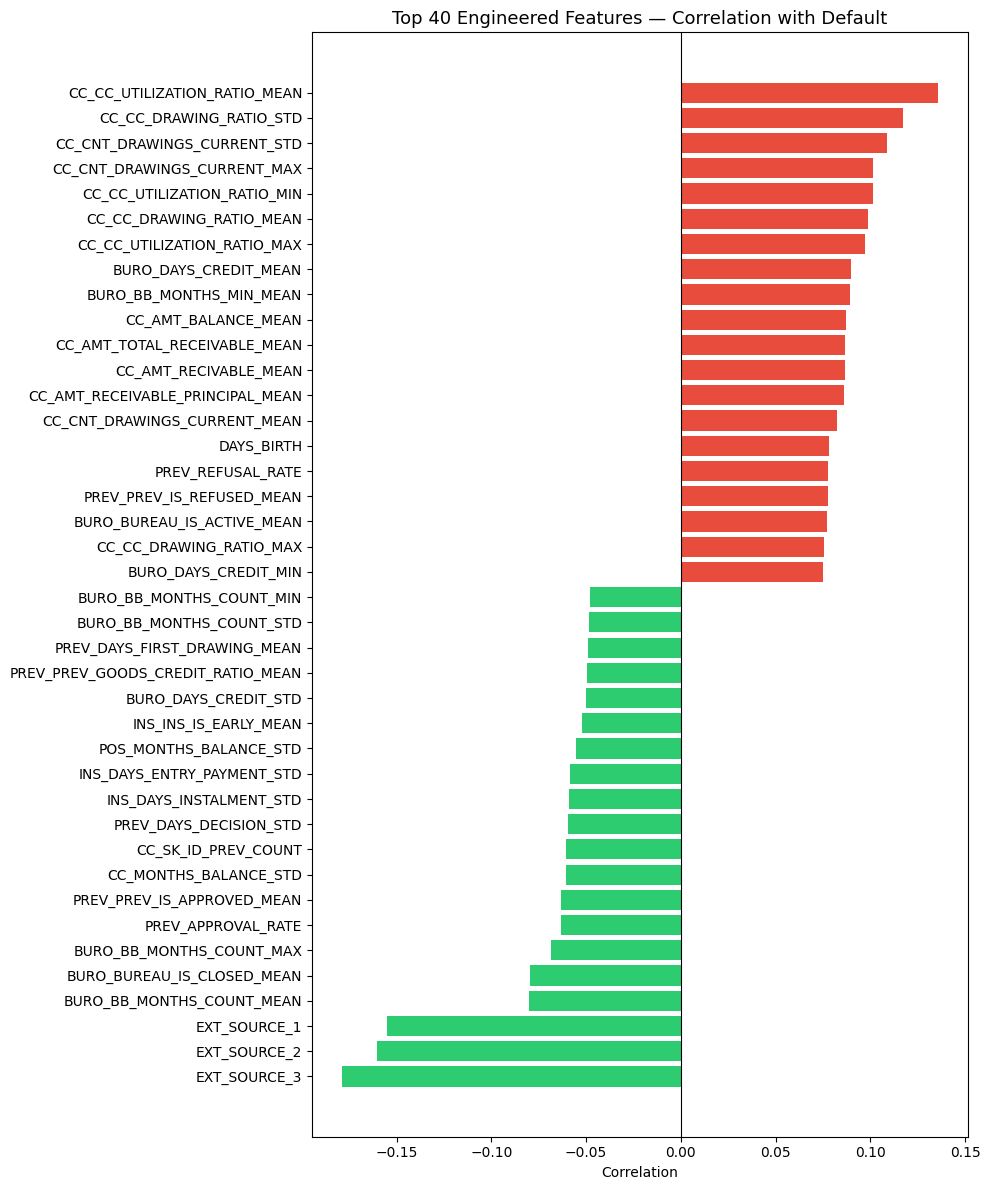

In [15]:
# Quick correlation check on new features with target
new_feat_corr = pd.Series(
    [X_train[col].corr(y_train) for col in X_train.columns],
    index=X_train.columns
).dropna().sort_values()

print("Top 15 POSITIVE correlations with target (→ higher default):")
print(new_feat_corr.tail(15).to_string())

print("\nTop 15 NEGATIVE correlations with target (→ lower default):")
print(new_feat_corr.head(15).to_string())

# Plot
fig, ax = plt.subplots(figsize=(10, 12))
top = pd.concat([new_feat_corr.head(20), new_feat_corr.tail(20)])
colors = ['#e74c3c' if v > 0 else '#2ecc71' for v in top.values]
ax.barh(top.index, top.values, color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Top 40 Engineered Features — Correlation with Default', fontsize=13)
ax.set_xlabel('Correlation')
plt.tight_layout()
plt.savefig('../outputs/fe_feature_importance_corr.png', dpi=150, bbox_inches='tight')
plt.show()